In [2]:
# Класс для первой выборки: Первый класс — точки внутри любой из двух разных
# пересекающихся полос, второй класс — прочие точки
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d, Axes3D
import time

In [3]:
def logistic(x, s=10):
    # логистическая функция активации
    return 1 / (1 + np.exp(-s*x))

def sign(x):
    # пороговая функция активации
    return (x > 0) * 1.

def relu(x):
    # ReLU-функция активации
    return x if x > 0 else 0.

class ManualMLP:
    # чтобы не лезть в детали реализации многослойного персептрона
    # в scikit-learn, сделаем свой маленький класс для него (без метода обучения,
    # т.е. только с ручным заданием коэффициентов)
    def __init__(self, coeffs, intercepts, act_func):
        # создать сеть по списку коэффициентов и функции активации
        self.coeffs = coeffs  # синаптические коэффициенты при входах
        self.intercepts = intercepts  # коэффициенты - постоянные (смещения нуля)
        self.act_func = act_func  # функция активации
        
    def predict(self, X):
        # получить выходы всех слоёв, а не только последнего
        curr_val = X
        results = []
        for i in range(len(self.coeffs)):
            # для каждого слоя провести линейное преобразование предыдущего
            curr_val = np.matmul(curr_val, self.coeffs[i]) + self.intercepts[i]
            # поместить его выход в результаты
            results.append(curr_val)
            # применить к этому же выходу нелинейное преобразование
            curr_val2 = self.act_func(curr_val)
            # поместить его тоже в результаты
            curr_val = curr_val2
            results.append(curr_val2)
        # выдать из функции и выход, и список результатов каждого слоя
        return curr_val, results


In [4]:
# создадим массивы коэффициентов, которые были в явном виде рассчитаны
# на лекции для задачи классификации
layer1_c = [[-1, -1, 2, 2],
            [1, 1, 1, 1]]
layer1_i = [1, -1, -4, -1]

layer2_c = [[-1, 0, 0, 1, 1],
            [0, 1, 0, -1, -1],
            [0, 0, -1, 1, 0],
            [0, 0, 1, 0, -1]]
layer2_i = [0.5, -0.5, -0.5, -1.5, -0.5]

layer3_c = [[0, 1],
            [0, 1],
            [0, 1],
            [1, 0],
            [1, 0]]
layer3_i = [-0.5, -0.5]


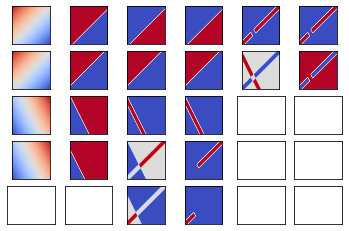

In [6]:
# создадим сеть с этими коэффициентами и пороговыми функциями активации всех слоёв
mlp = ManualMLP([np.array(layer1_c), np.array(layer2_c), np.array(layer3_c)],
                [np.array(layer1_i), np.array(layer2_i), np.array(layer3_i)],
                sign)

# обучать сеть не надо, потому что коэффициенты для неё мы рассчитали вручную;
# можно просто вывести её результаты для рассматриваемой области данных

def draw_all_layers_output(net, min_x, max_x, min_y, max_y, dx, dy):
    # функция вывода результатов работы всех нейронов сети net;
    # принимает она два числа -- первое принимает значения
    # от min_x до max_x с шагом dx, второе --- от min_y до max_y с шагом dy
    # Вычислим размер входных данных
    nx = round((max_x - min_x) / dx) + 1
    ny = round((max_y - min_y) / dy) + 1
    # составим из них решётку --- пару матриц vx,vy, в которых 
    # сочетаются все возможные пары x и y
    px = np.linspace(min_x, max_x, nx)
    py = np.linspace(min_x, max_x, ny)
    vx, vy = np.meshgrid(px, py)
    test_set = np.vstack([np.ravel(vx), np.ravel(vy)]).T
    # предскажем классы всех элементов решётки на нейросети
    preds,interm = net.predict(test_set)
    
    # выведем эти классы
    fig, axs = plt.subplots(nrows=5, ncols=6)
    # размеры слоёв сети
    szs = [interm[i].shape[1] for i in range(len(interm))]
    
    for i,sz in enumerate(szs):
        for j in range(sz):
            # для каждого используемого нейрона вывести выход в виде изображения
            reshaped_data = np.reshape(interm[i][:,j], (nx, ny))
            dt = np.flip(reshaped_data, 0)
            axs[j, i].imshow(dt, cmap=cm.coolwarm)
            axs[j, i].set_xticks([])
            axs[j, i].set_yticks([])
            # неиспользуемыми оставить пустыми
            for j in range(sz, max(szs)):
                axs[j, i].set_xticks([])
                axs[j, i].set_yticks([])
    plt.show()

# выведем выходы всех нейронов сети mlp в диапазонах x и y [-3,10]
# с шагом x и y 0.1. Слои выводятся слева направо; для каждого нейрона 
# выводится сначала сумма входов, а потом результат действия функции активации
# на эту сумму.

draw_all_layers_output(mlp, -3, 10, -5, 8, 0.1, 0.1)

/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Network with l1=2 and l2=2 processed in experiment 1


/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Network with l1=2 and l2=3 processed in experiment 1


/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Network with l1=5 and l2=4 processed in experiment 3


/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Network with l1=5 and l2=5 processed in experiment 3


/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Network with l1=5 and l2=6 processed in experiment 3
[[0.76306602 0.95135989 0.8501598  0.96174839 0.62023115]
 [0.12981942 0.65956607 0.75036055 0.96234652 0.44723986]
 [0.45049453 0.972708   0.95178189 0.76913901 0.94761128]
 [0.15050505 0.62769163 0.57834772 0.96790667 0.96411373]]
[[0.5839599  0.36967419 0.21616541 0.39536341 0.29699248]
 [0.33333333 0.22556391 0.53571429 0.48621554 0.49561404]
 [0.47619048 0.50501253 0.45050125 0.66165414 0.53258145]
 [0.28007519 0.36278195 0.85526316 0.49874687 0.55889724]]


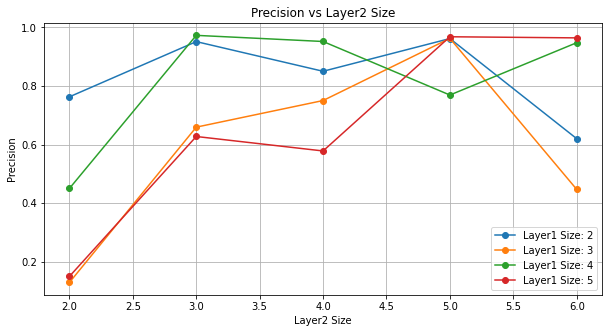

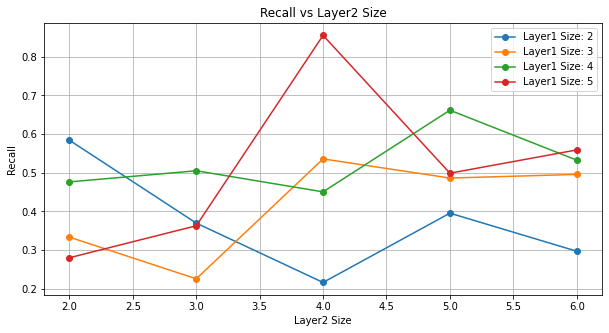

Layer1 Size: 2, Layer2 Size: 2
Precision: 0.7631, Recall: 0.5840

Layer1 Size: 2, Layer2 Size: 3
Precision: 0.9514, Recall: 0.3697

Layer1 Size: 2, Layer2 Size: 4
Precision: 0.8502, Recall: 0.2162

Layer1 Size: 2, Layer2 Size: 5
Precision: 0.9617, Recall: 0.3954

Layer1 Size: 2, Layer2 Size: 6
Precision: 0.6202, Recall: 0.2970

Layer1 Size: 3, Layer2 Size: 2
Precision: 0.1298, Recall: 0.3333

Layer1 Size: 3, Layer2 Size: 3
Precision: 0.6596, Recall: 0.2256

Layer1 Size: 3, Layer2 Size: 4
Precision: 0.7504, Recall: 0.5357

Layer1 Size: 3, Layer2 Size: 5
Precision: 0.9623, Recall: 0.4862

Layer1 Size: 3, Layer2 Size: 6
Precision: 0.4472, Recall: 0.4956

Layer1 Size: 4, Layer2 Size: 2
Precision: 0.4505, Recall: 0.4762

Layer1 Size: 4, Layer2 Size: 3
Precision: 0.9727, Recall: 0.5050

Layer1 Size: 4, Layer2 Size: 4
Precision: 0.9518, Recall: 0.4505

Layer1 Size: 4, Layer2 Size: 5
Precision: 0.7691, Recall: 0.6617

Layer1 Size: 4, Layer2 Size: 6
Precision: 0.9476, Recall: 0.5326

Layer1 Siz

/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/artem/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/artem/.local/lib/python3.10/site-packages/skle

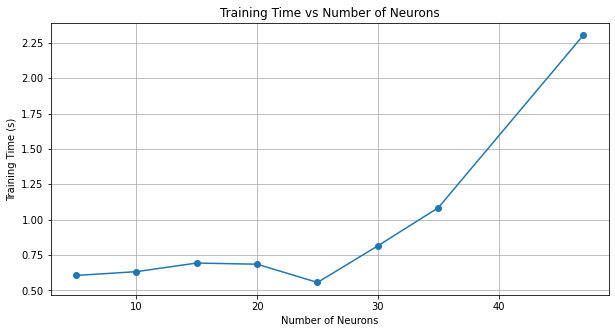

In [10]:
# Генерация точек внутри шара
num_points = 1000
radius = 0.5
center = np.array([0, -0.5, 0])

points_sphere = np.random.randn(num_points, 3)
points_sphere = points_sphere / np.linalg.norm(points_sphere, axis=1, keepdims=True) * radius
points_sphere += center

# Генерация точек ниже плоскости
points_plane = np.random.randn(num_points, 3)
points_plane = points_plane[points_plane[:, 0] - points_plane[:, 1] + points_plane[:, 2] < -3]

# Генерация точек между плоскостями
points_between_planes = np.random.randn(num_points, 3)
points_between_planes = points_between_planes[(0.2 * points_between_planes[:, 0] + 0.2 * points_between_planes[:, 1] + points_between_planes[:, 2] > -1) &
                                              (0.2 * points_between_planes[:, 0] + 0.2 * points_between_planes[:, 1] + points_between_planes[:, 2] < 1)]

# Объединение точек внутри шара и точек ниже плоскости в один класс
class_1 = np.vstack((points_sphere, points_plane))
class_2 = points_between_planes

# Создание меток для классов
labels_1 = np.zeros(len(class_1))
labels_2 = np.ones(len(class_2))

# Объединение данных и меток
data = np.vstack((class_1, class_2))
labels = np.hstack((labels_1, labels_2))

points_train, points_test, classes_train, classes_test = train_test_split(data, labels, test_size=0.8, random_state=17, shuffle=True)

# Проверяемые размеры слоёв
layer1_sizes = [2, 3, 4, 5]
layer2_sizes = [2, 3, 4, 5, 6]

# Массивы для результатов
precisions = np.zeros((len(layer1_sizes), len(layer2_sizes)))
recalls = np.zeros((len(layer1_sizes), len(layer2_sizes)))

# Число повторов проверок (т.е. число обучаемых нейросетей каждой конфигурации)
NE = 3

for e_num in range(NE):
    for i, layer1_size in enumerate(layer1_sizes):
        for j, layer2_size in enumerate(layer2_sizes):
            # Создаем сеть с числом нейронов скрытых слоёв, равным (layer1_size, layer2_size)
            mlp = MLPClassifier(hidden_layer_sizes=(layer1_size, layer2_size), activation='relu')
            # Обучаем классификатор на обучающей выборке
            mlp.fit(points_train, np.ravel(classes_train))
            # Предсказываем классы для тестовой выборки
            classes_predicted = mlp.predict(points_test)
            # Вырабатываем оценку качества
            rep = classification_report(classes_test, classes_predicted, output_dict=True)
            #print(rep)

            # Выбираем из результатов precision и recall для класса 1
            precisions[i, j] += rep['1.0']['precision']
            recalls[i, j] += rep['1.0']['recall']
            print(f'Network with l1={layer1_size} and l2={layer2_size} processed in experiment {e_num + 1}')

# Усредняем собранные данные
precisions /= NE
recalls /= NE

# Выводим их в явном виде на всякий случай
print(precisions)
print(recalls)


# График зависимости precision от размеров слоёв
plt.figure(figsize=(10, 5))
for i, layer1_size in enumerate(layer1_sizes):
    plt.plot(layer2_sizes, precisions[i], marker='o', label=f'Layer1 Size: {layer1_size}')
plt.xlabel('Layer2 Size')
plt.ylabel('Precision')
plt.title('Precision vs Layer2 Size')
plt.legend()
plt.grid(True)
plt.show()

# График зависимости recall от размеров слоёв
plt.figure(figsize=(10, 5))
for i, layer1_size in enumerate(layer1_sizes):
    plt.plot(layer2_sizes, recalls[i], marker='o', label=f'Layer1 Size: {layer1_size}')
plt.xlabel('Layer2 Size')
plt.ylabel('Recall')
plt.title('Recall vs Layer2 Size')
plt.legend()
plt.grid(True)
plt.show()

# Сравнение результатов для тестовой и обучающей выборки
for i, layer1_size in enumerate(layer1_sizes):
    for j, layer2_size in enumerate(layer2_sizes):
        print(f"Layer1 Size: {layer1_size}, Layer2 Size: {layer2_size}")
        print(f"Precision: {precisions[i, j]:.4f}, Recall: {recalls[i, j]:.4f}")
        print()
# Измерение времени обучения для различных чисел нейронов в первом скрытом слое
num_neurons_list = [5 * i for i in range(1, 8)] + [47]
training_times = []

for num_neurons in num_neurons_list:
    start_time = time.time()
    mlp = MLPClassifier(hidden_layer_sizes=(num_neurons,), activation='logistic', learning_rate_init = 0.02)
    mlp.fit(points_train, np.ravel(classes_train))
    end_time = time.time()
    training_times.append(end_time - start_time)

# График зависимости длительности обучения от числа нейронов
plt.figure(figsize=(10, 5))
plt.plot(num_neurons_list, training_times, marker='o')
plt.xlabel('Number of Neurons')
plt.ylabel('Training Time (s)')
plt.title('Training Time vs Number of Neurons')
plt.grid(True)
plt.show()